# 02 — Demand Distribution
**Phase 2: Clean Daily Demand → Empirical P(D) with Dirichlet Smoothing**

**Reads:** `../data/processed/sandwich_daily_demand_cleaned.csv`

**Writes:**
- `../data/processed/sandwich_P_of_D.csv`
- `../outputs/figures/demand_pmf.png`
- `../outputs/figures/demand_cdf.png`

**Why Dirichlet smoothing:** The raw empirical PMF assigns zero probability to demand values never observed. In simulation, zeros mean those outcomes can NEVER occur. Dirichlet smoothing adds α pseudo-counts to every bin, ensuring full support while preserving the distribution shape.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = "../data/processed"
FIG_DIR  = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

ALPHA = 1.0  # Dirichlet smoothing parameter

## 1. Load cleaned demand and build PMF

In [20]:
df = pd.read_csv(os.path.join(DATA_DIR, "sandwich_daily_demand_cleaned.csv"), parse_dates=["Date"])
D = df["Daily_Demand"].astype(int)
print(f"Loaded {len(D)} daily demand observations")

# Unsmoothed empirical PMF
counts = D.value_counts().sort_index()
Dmax = int(D.max())
support = range(Dmax + 1)
P_unsmoothed = counts.reindex(support, fill_value=0) / counts.sum()

# Dirichlet smoothed PMF
counts_full = counts.reindex(support, fill_value=0)
K = len(support)
P_smoothed = (counts_full + ALPHA) / (counts_full.sum() + ALPHA * K)

# Combine
P = pd.DataFrame({"P_unsmoothed": P_unsmoothed, "P_smoothed": P_smoothed})
P.index.name = "Demand_D"

# Sanity checks
assert abs(P["P_unsmoothed"].sum() - 1.0) < 1e-10
assert abs(P["P_smoothed"].sum() - 1.0) < 1e-10
assert (P["P_smoothed"] > 0).all()
print("Sanity checks passed")

# Save
P.reset_index().to_csv(os.path.join(DATA_DIR, "sandwich_P_of_D.csv"), index=False)
print("Saved: sandwich_P_of_D.csv")
print(P)

Loaded 364 daily demand observations
Sanity checks passed
Saved: sandwich_P_of_D.csv
          P_unsmoothed  P_smoothed
Demand_D                          
0             0.043956    0.043590
1             0.032967    0.033333
2             0.035714    0.035897
3             0.065934    0.064103
4             0.043956    0.043590
5             0.065934    0.064103
6             0.079670    0.076923
7             0.071429    0.069231
8             0.096154    0.092308
9             0.068681    0.066667
10            0.041209    0.041026
11            0.057692    0.056410
12            0.052198    0.051282
13            0.027473    0.028205
14            0.038462    0.038462
15            0.030220    0.030769
16            0.030220    0.030769
17            0.032967    0.033333
18            0.021978    0.023077
19            0.013736    0.015385
20            0.016484    0.017949
21            0.010989    0.012821
22            0.008242    0.010256
23            0.005495    0.007692
24   

## 2. Distribution statistics

In [21]:
vals = P.index.to_numpy()
probs = P["P_smoothed"].to_numpy()
E_D = np.sum(vals * probs)
Var_D = np.sum(probs * (vals - E_D)**2)
cdf = np.cumsum(probs)

print(f"E[D]   = {E_D:.2f}")
print(f"Var[D] = {Var_D:.2f}  (SD = {np.sqrt(Var_D):.2f})")
print(f"Median = {vals[np.searchsorted(cdf, 0.5)]}")
print(f"P95    = {vals[np.searchsorted(cdf, 0.95)]}")
print(f"CV     = {np.sqrt(Var_D)/E_D:.2f}")

E[D]   = 9.20
Var[D] = 33.47  (SD = 5.79)
Median = 8
P95    = 20
CV     = 0.63


## 3. Plot PMF

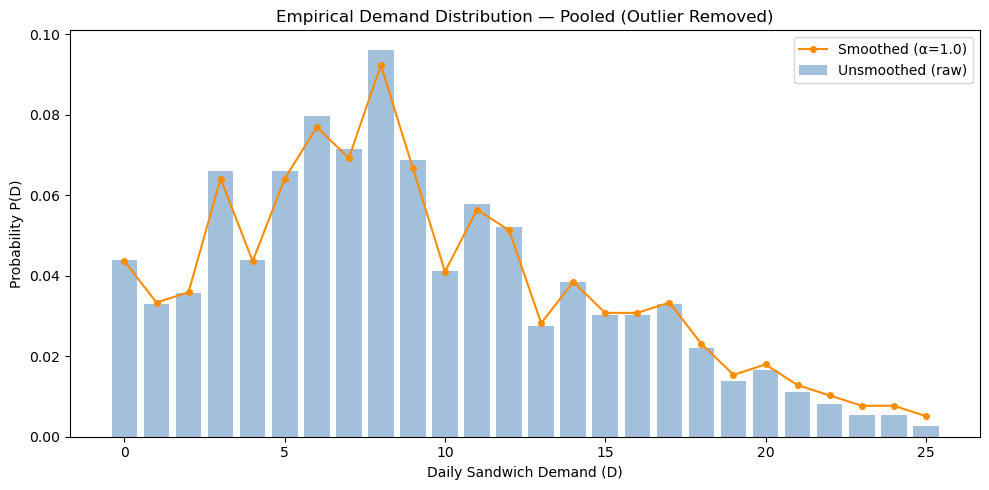

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(P.index, P["P_unsmoothed"], alpha=0.5, label="Unsmoothed (raw)", color="steelblue")
ax.plot(P.index, P["P_smoothed"], marker="o", markersize=4, linestyle="-",
        label=f"Smoothed (α={ALPHA})", color="darkorange")
ax.set_xlabel("Daily Sandwich Demand (D)")
ax.set_ylabel("Probability P(D)")
ax.set_title("Empirical Demand Distribution — Pooled (Outlier Removed)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "demand_pmf.png"), dpi=150)
plt.show()

## 4. Plot CDF

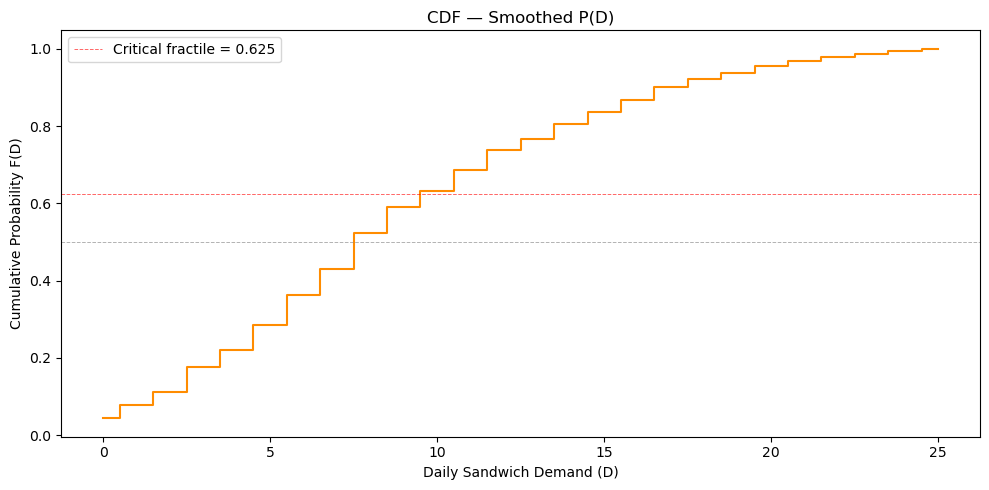

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.step(P.index, np.cumsum(P["P_smoothed"]), where="mid", linewidth=1.5, color="darkorange")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.7, alpha=0.6)
ax.axhline(0.625, color="red", linestyle="--", linewidth=0.7, alpha=0.6, label="Critical fractile = 0.625")
ax.set_xlabel("Daily Sandwich Demand (D)")
ax.set_ylabel("Cumulative Probability F(D)")
ax.set_title("CDF — Smoothed P(D)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "demand_cdf.png"), dpi=150)
plt.show()